### **8.7 Full EDA Project: Putting It All Together**

**Goal:**

Perform a complete end-to-end EDA workflow on a dataset and identify
what preprocessing steps are required before modeling.

**Dataset:**

insurance.csv

---

### **1. Setup**

In [2]:
%pip install -q numpy pandas matplotlib seaborn scipy


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_style("whitegrid")

### **2. Load the Dataset**

In [4]:
df = pd.read_csv("insurance.csv")

In [6]:
df.shape

(1338, 7)

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


**Column Details:**

| Column    | Description                                                | Feature Type                   |
|-----------|------------------------------------------------------------|--------------------------------|
| age       | Age of the individual                                      | Numerical (continuous)         |
| sex       | Gender of the individual (male or female)                  | Categorical                    |
| bmi       | Body Mass Index, a measure of body fat based on weight and height | Numerical (continuous)  |
| children  | Number of dependent children covered by the insurance plan | Numerical (discrete)           |
| smoker    | Whether the individual is a smoker (yes or no)             | Categorical (binary)           |
| region    | Residential region in the US (northeast, northwest, southeast, southwest) | Categorical |
| charges   | Medical insurance cost billed to the individual            | Numerical (continuous, target) |

### **3. Data Quality Checks**

**3.1. Basic dataset overview**

In [8]:
# identify numerical & categorical features
num_cols = ["age", "bmi", "children", "charges"]
cat_cols = ["sex", "smoker", "region"]

print("\nNumerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: ['age', 'bmi', 'children', 'charges']
Categorical columns: ['sex', 'smoker', 'region']


In [10]:
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())

print("-"*50)

print("\nData types:")
print(df.dtypes)

print("-"*50)

print("\nUnique values per column:")
print(df.nunique())

Shape: (1338, 7)

Column names:
 ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
--------------------------------------------------

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
--------------------------------------------------

Unique values per column:
age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64


In [11]:
print("\nFirst pass info:")
print(df.info())


First pass info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [12]:
# descriptive statistics
df[num_cols].describe()

,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


**3.2. Missing Values - Analysis**

In [13]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [14]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(2)
})

print("Missing values summary:")
missing_summary

Missing values summary:


,missing_count,missing_percent
age,0,0.000
sex,0,0.000
bmi,0,0.000
children,0,0.000
smoker,0,0.000
region,0,0.000
charges,0,0.000


**NOTE: No missing values in the dataset. Still need to verify encoded missing values.**

**example: -999, 999, unknown**

In [15]:
for col in df.columns:
    print(df[col].value_counts())
    print("-"*50)

age
18    69
19    68
50    29
51    29
47    29
46    29
45    29
20    29
48    29
52    29
22    28
49    28
54    28
53    28
21    28
26    28
24    28
25    28
28    28
27    28
23    28
43    27
29    27
30    27
41    27
42    27
44    27
31    27
40    27
32    26
33    26
56    26
34    26
55    26
57    26
37    25
59    25
58    25
36    25
38    25
35    25
39    25
61    23
60    23
63    23
62    23
64    22
Name: count, dtype: int64
--------------------------------------------------
sex
male      676
female    662
Name: count, dtype: int64
--------------------------------------------------
bmi
32.300    13
28.310     9
30.495     8
30.875     8
31.350     8
          ..
46.200     1
23.800     1
44.770     1
32.120     1
30.970     1
Name: count, Length: 548, dtype: int64
--------------------------------------------------
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64
--------------------------------------------------
smoker
no 

Note: No encoded missing values

**3.3. Duplicates**

In [16]:
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicate rows:", num_duplicates)
print("Duplicated row:\n",df[duplicate_mask])
 
# If you want to remove duplicates:
df_no_duplicates = df.drop_duplicates()
print("Shape after dropping duplicates:", df_no_duplicates.shape)

Number of duplicate rows: 1
Duplicated row:
      age   sex    bmi  children smoker     region  charges
581   19  male 30.590         0     no  northwest 1639.563
Shape after dropping duplicates: (1337, 7)


In [17]:
# list of columns
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

**3.4. Data Type Validation**

In [18]:
expected_types = {
    "age": "int64",
    "sex": "object",
    "bmi": "float64",
    "children": "int64",
    "smoker": "object",
    "region": "object",
    "charges": "float64"
}

print("Data type validation:")
for col, expected in expected_types.items():
    if col in df.columns:
        actual = df[col].dtype
        print(f"{col}: actual={actual}, expected={expected}")

Data type validation:
age: actual=int64, expected=int64
sex: actual=object, expected=object
bmi: actual=float64, expected=float64
children: actual=int64, expected=int64
smoker: actual=object, expected=object
region: actual=object, expected=object
charges: actual=float64, expected=float64


**3.5. Constant and quasi constant columns**

In [19]:
n_rows = len(df)
nunique = df.nunique()

constant_cols = nunique[nunique == 1].index.tolist()
print("Constant columns:", constant_cols)

# Quasi constant: top value more than 95 percent
quasi_constant_cols = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
    if top_freq > 0.95 and col not in constant_cols:
        quasi_constant_cols.append(col)

print("Quasi constant columns (top value more than 95 percent):", quasi_constant_cols)

Constant columns: []
Quasi constant columns (top value more than 95 percent): []


**NOTE: No constant / quasi-constant columns**

**3.6. ID like columns**

In [21]:
# NOTE: charges should not be considered id-like even if all the value are unique
id_like_cols = []

for col in df.columns:
    if df[col].nunique(dropna=False) == n_rows:
        id_like_cols.append(col)

print("ID like columns:", id_like_cols)

ID like columns: []


In [22]:
# skipping string inconsistency as it is not critical and value counts doesn't seem to show any in string column
# no null columns

**3.7. High zero columns (numeric)**

In [24]:
zero_share = {}

for col in num_cols:
    zero_share[col] = (df[col] == 0).mean()

zero_share_series = pd.Series(zero_share).sort_values(ascending=False)
zero_share_series

high_zero_threshold = 0.8  # 80 percent or more zeros
high_zero_cols = zero_share_series[zero_share_series >= high_zero_threshold]
print("Numeric columns with many zeros:")
high_zero_cols

Numeric columns with many zeros:


Series([], dtype: float64)

Insight: No zero columns

**3.8. Data Quality Check - summary**

In [26]:
print("Data quality checklist summary")
print("- Shape and columns checked")
print("- Missing values summary created (None)")
print("- Duplicates counted and removable copy created")
print("- Data types compared with expectations")
print("- Constant and quasi constant columns flagged (None)")
print("- ID like columns detected (None)")
print("- High zero numeric columns identified")

Data quality checklist summary
- Shape and columns checked
- Missing values summary created (None)
- Duplicates counted and removable copy created
- Data types compared with expectations
- Constant and quasi constant columns flagged (None)
- ID like columns detected (None)
- High zero numeric columns identified


### **4. Univariate Analysis**

**Numerical Features - Analysis**

**4.1. Descriptive Statistics - Summary**

In [27]:
print("Summary statistics:")
df[num_cols].describe()

Summary statistics:


,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


**4.2. Central Tendency - Mean, Median, Mode**

In [28]:
print("Mean:")
print(df[num_cols].mean())

print("-"*50)

print("Median:")
print(df[num_cols].median())

print("-"*50)

print("Mode:")
print(df[num_cols].mode().iloc[0])

Mean:
age           39.207
bmi           30.663
children       1.095
charges    13270.422
dtype: float64
--------------------------------------------------
Median:
age          39.000
bmi          30.400
children      1.000
charges    9382.033
dtype: float64
--------------------------------------------------
Mode:
age          18.000
bmi          32.300
children      0.000
charges    1639.563
Name: 0, dtype: float64


**4.3. Measure of Spread - Variance & Standard Deviation**

In [29]:
print("Variance:")
print(df[num_cols].var())

print("-"*50)

print("Standard Deviation:")
print(df[num_cols].std())

Variance:
age              197.401
bmi               37.188
children           1.453
charges    146652372.153
dtype: float64
--------------------------------------------------
Standard Deviation:
age           14.050
bmi            6.098
children       1.205
charges    12110.011
dtype: float64


**4.4. Skewness & Kurtosis**

In [30]:
print("\nSkewness:")
print(df[num_cols].skew())

print("\nKurtosis:")
print(df[num_cols].kurtosis())


Skewness:
age        0.056
bmi        0.284
children   0.938
charges    1.516
dtype: float64

Kurtosis:
age        -1.245
bmi        -0.051
children    0.202
charges     1.606
dtype: float64


**4.5. Histograms - Distributions**

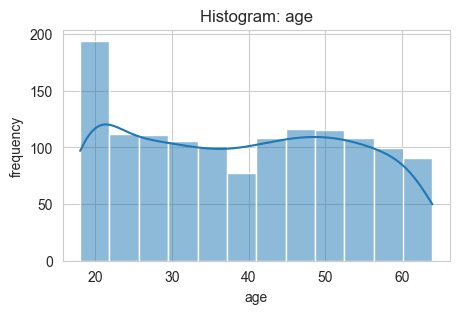

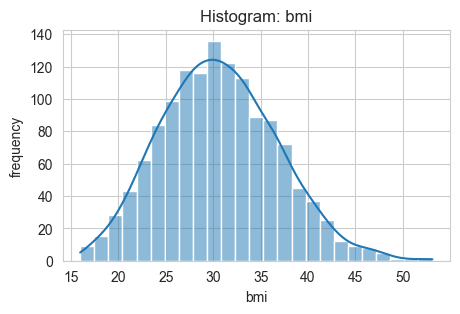

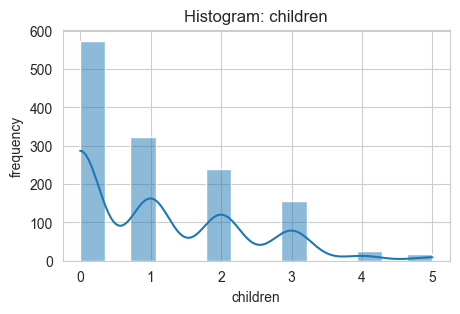

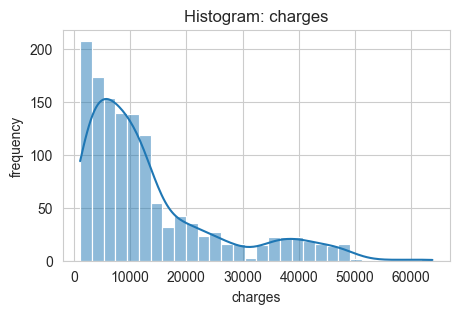

In [31]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

**Inference: Skewness in children & charges column**

**4.6. Boxplot - Outliers**

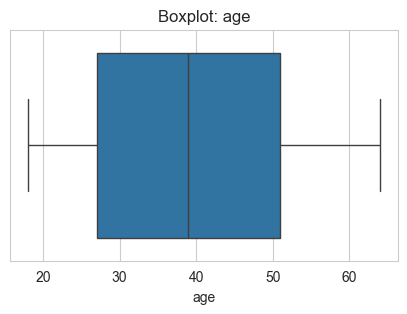

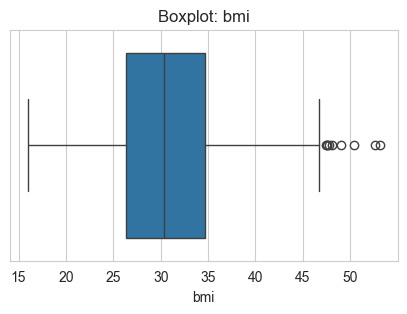

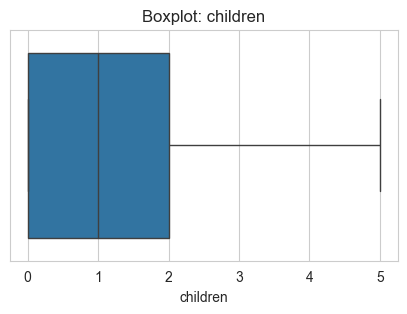

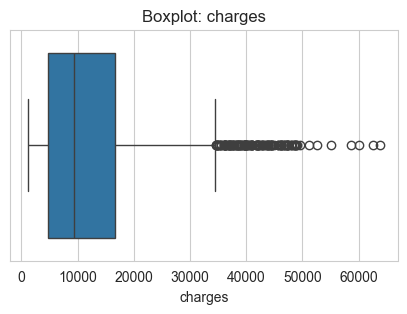

In [32]:
for col in num_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()

**Inference:** There are several outliers in "charges" column (target). The ML model would not be able to provide accurate predictions throughout the range. Transformations should be applied in pre-processing step to address this

**Categorical Features - Analysis**

In [33]:
print(cat_cols)

['sex', 'smoker', 'region']


In [35]:
df[cat_cols].head()

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


**4.7. Frequency Table**

In [36]:
for col in cat_cols:
    print(f"Frequency table for {col}")
    print(df[col].value_counts())
    print(f"Proportion for {col}")
    print(df[col].value_counts(normalize=True))
    print("-"*50)

Frequency table for sex
sex
male      676
female    662
Name: count, dtype: int64
Proportion for sex
sex
male     0.505
female   0.495
Name: proportion, dtype: float64
--------------------------------------------------
Frequency table for smoker
smoker
no     1064
yes     274
Name: count, dtype: int64
Proportion for smoker
smoker
no    0.795
yes   0.205
Name: proportion, dtype: float64
--------------------------------------------------
Frequency table for region
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
Proportion for region
region
southeast   0.272
southwest   0.243
northwest   0.243
northeast   0.242
Name: proportion, dtype: float64
--------------------------------------------------


**Inference:** imbalance in "smoker" column

**4.8. Countplot**

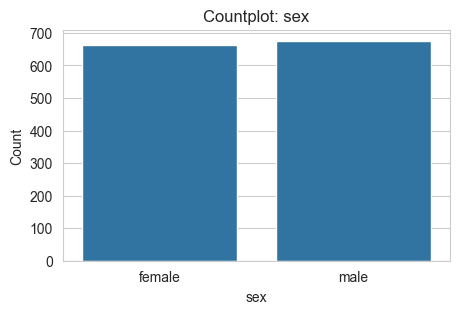

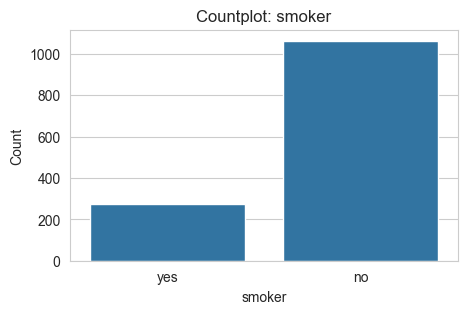

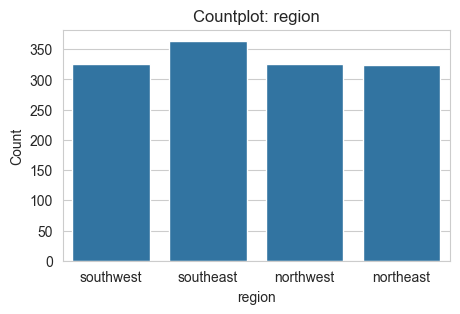

In [37]:
for col in cat_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df[col])
    plt.title(f"Countplot: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

**4.9. Univariate Analysis - Summary**

In [39]:
print("Univariate analysis completed.")
print("- Numerical statistics calculated")
print("- Skewness and kurtosis printed")
print("- Histograms and boxplots plotted")
print("- Categorical frequency tables and countplots created")

Univariate analysis completed.
- Numerical statistics calculated
- Skewness and kurtosis printed
- Histograms and boxplots plotted
- Categorical frequency tables and countplots created


### **5. Bivariate Analysis**

In [41]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [43]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [44]:
print("Numerical Columns", num_cols)
print("Categorical Columns", cat_cols)

Numerical Columns ['age', 'bmi', 'children', 'charges']
Categorical Columns ['sex', 'smoker', 'region']


**Numerical vs Numerical Features**

**5.1. Scatter Plot**

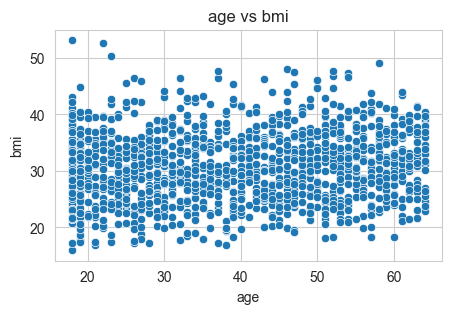

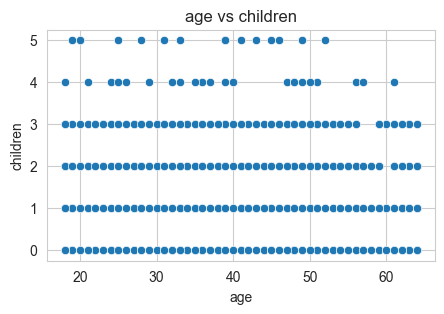

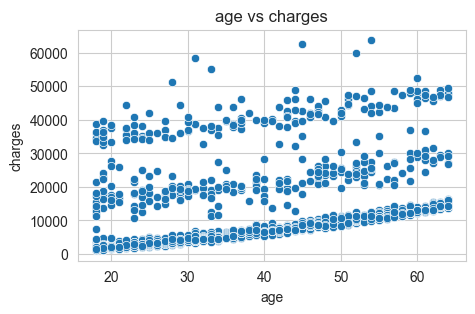

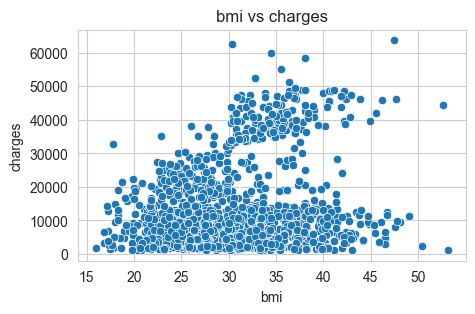

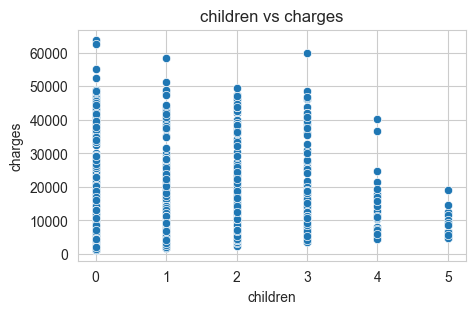

In [45]:
num_pairs = [
    ("age", "bmi"),
    ("age", "children"),
    ("age", "charges"),
    ("bmi", "charges"),
    ("children", "charges")
]

for x, y in num_pairs:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df[x], y=df[y])
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

**Inference:** SLight positive correlation between:
- age vs charges
- BMI & charges 

**5.2. Correlation Matrix**

In [46]:
print("Correlation Matrix")
df[num_cols].corr()

# -1 -> high negative correlation; +1 -> high positive correlation

Correlation Matrix


,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


In [47]:
print("Pearson Correlation with fare:")
for col in num_cols:
    if col != "age":
        r, p = pearsonr(df[col], df["age"])
        print(f"{col} vs age: r={r:.3f}; p={p:.3f}")

# r, p; r -> correlation coefficient (-1 to +1); p -> small val (0.05) -> strong confidence; high -> random coincidence 

Pearson Correlation with fare:
bmi vs age: r=0.109; p=0.000
children vs age: r=0.042; p=0.120
charges vs age: r=0.299; p=0.000


**Inference:** SLight positive correlation between:
- age vs charges
- BMI & charges 

**Numerical vs Categorical Features**

**5.3. Boxplots**

In [48]:
print(num_cols)
print(cat_cols)

['age', 'bmi', 'children', 'charges']
['sex', 'smoker', 'region']


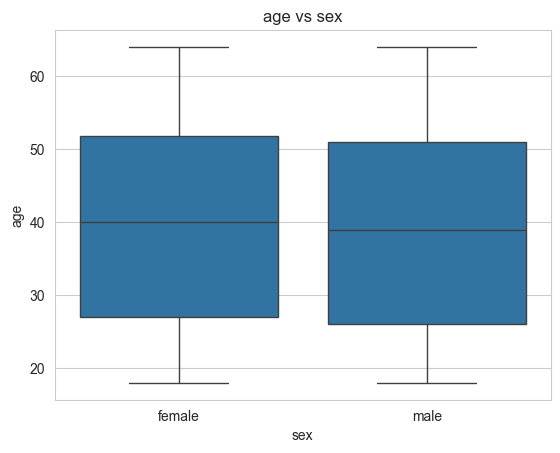

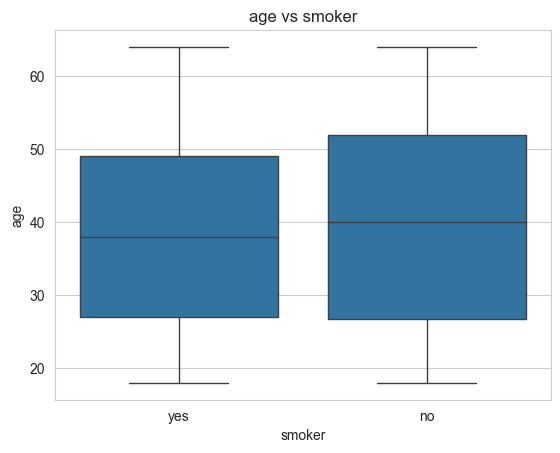

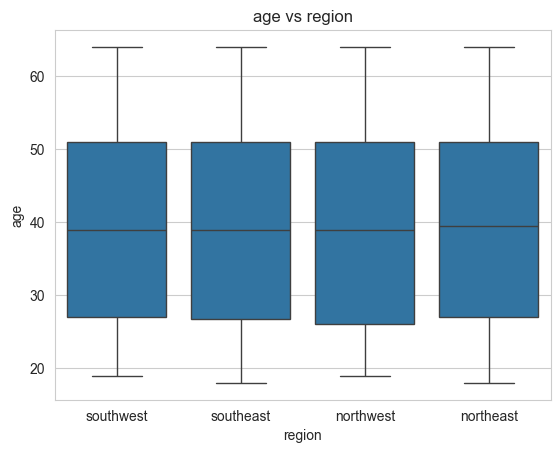

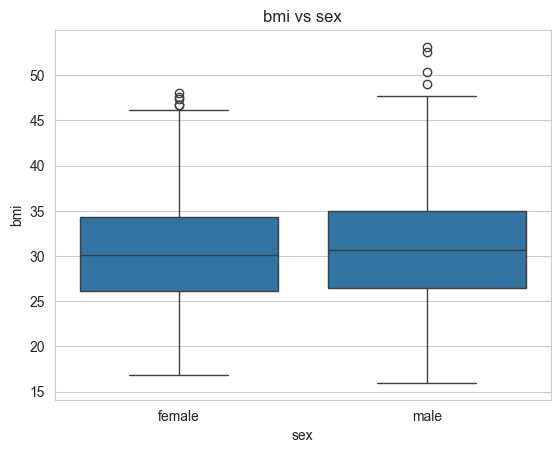

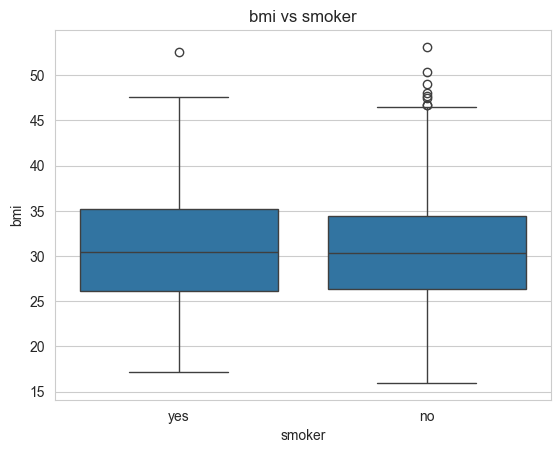

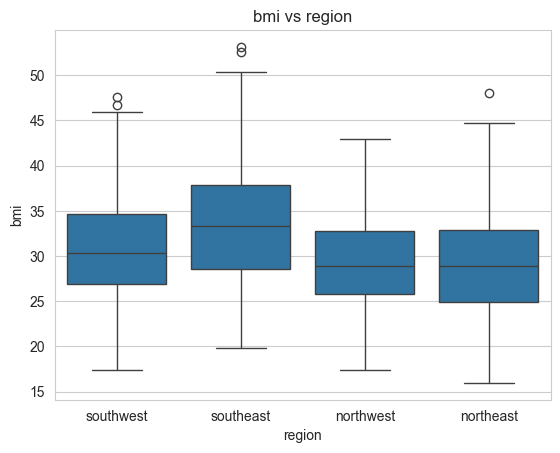

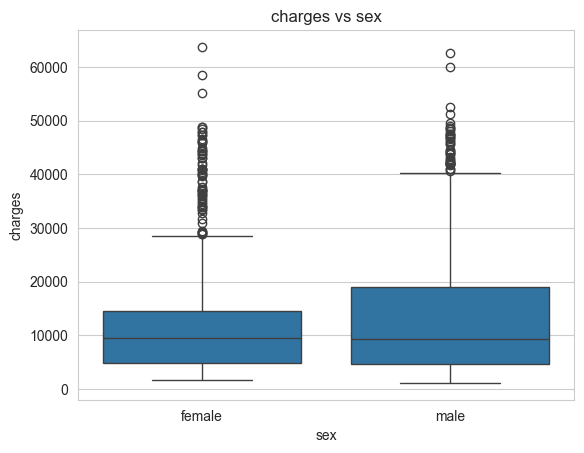

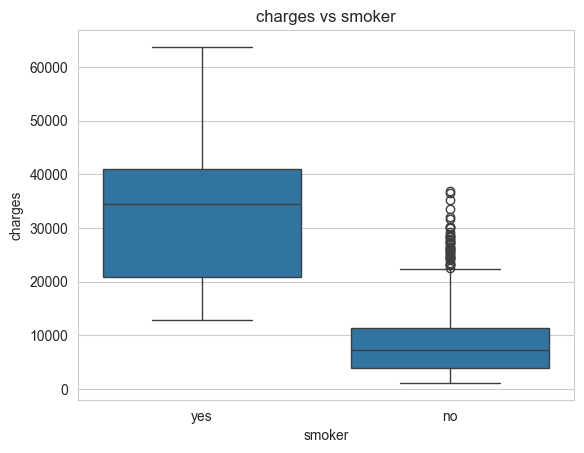

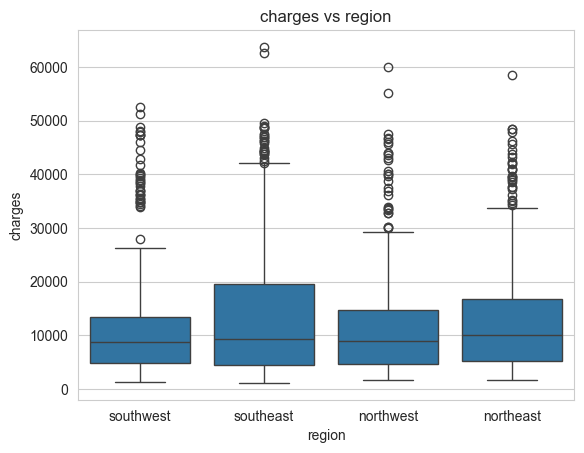

In [49]:
num_for_box = ["age", "bmi", "charges"]
cat_for_box = ["sex", "smoker", "region"]

for num in num_for_box:
    for cat in cat_for_box:
        plt.Figure(figsize=(5,3))
        sns.boxplot(x=df[cat], y=df[num])
        plt.title(f"{num} vs {cat}")
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.show()

**Inference:** 
- Important: Insurance charges very high for smokers compared to non-smokers
- Important: More number of female have lesser charges compared to male (maybe related to smoker - if gender based)
- median age of non-smoker slightly higher than smokers
- similar median charges across different regions

**5.4. Grouped Statistics**

In [51]:
df[num_cols + ["sex"]].groupby("sex").mean()

,age,bmi,children,charges
sex,,,,
female,39.503,30.378,1.074,12569.579
male,38.917,30.943,1.115,13956.751


In [53]:
for category in ["sex", "smoker", "region"]:
    print(df[num_cols + [category]].groupby(category).mean())
    print("-"*50)

          age    bmi  children   charges
sex                                     
female 39.503 30.378     1.074 12569.579
male   38.917 30.943     1.115 13956.751
--------------------------------------------------
          age    bmi  children   charges
smoker                                  
no     39.385 30.652     1.090  8434.268
yes    38.515 30.708     1.113 32050.232
--------------------------------------------------
             age    bmi  children   charges
region                                     
northeast 39.269 29.174     1.046 13406.385
northwest 39.197 29.200     1.148 12417.575
southeast 38.940 33.356     1.049 14735.411
southwest 39.455 30.597     1.142 12346.937
--------------------------------------------------


**Inference:** 
- higher charges for smokers
- region based slight increase in charges

**Categorical vs Categorical Features**

**5.5. Crosstab**

In [55]:
# we don't have much combinations to play with
print("Crosstab: sex vs smoker")
print(pd.crosstab(df["sex"], df["smoker"]))

print("Crosstab: smoker vs region")
print(pd.crosstab(df["smoker"], df["region"]))

Crosstab: sex vs smoker
smoker   no  yes
sex             
female  547  115
male    517  159
Crosstab: smoker vs region
region  northeast  northwest  southeast  southwest
smoker                                            
no            257        267        273        267
yes            67         58         91         58


Not much information to work with in crosstab & countplot

**Idea to work with later:** Categorize "charges" column to "high" & "low"; Then try looking for some insights with relationships with other categorical columns

**5.6. Countplot**

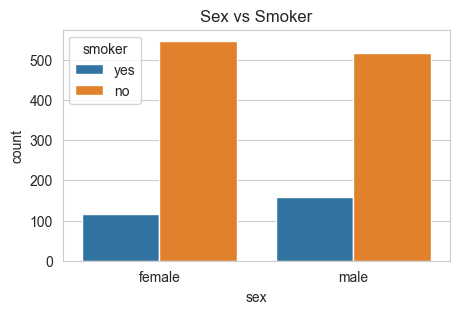

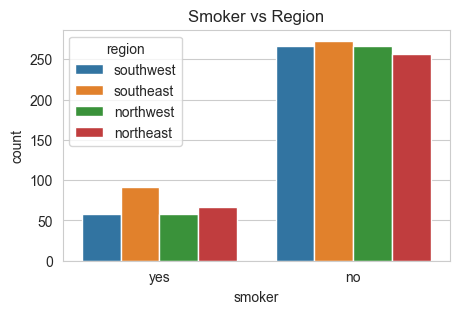

In [56]:
plt.figure(figsize=(5,3))
sns.countplot(x=df["sex"], hue=df["smoker"])
plt.title("Sex vs Smoker")
plt.show()


plt.figure(figsize=(5,3))
sns.countplot(x=df["smoker"], hue=df["region"])
plt.title("Smoker vs Region")
plt.show()

**5.7. Bivariate Analysis - Summary**

In [57]:
print("\nBivariate Analysis Completed")
print("- Numerical vs numerical: scatter + correlations")
print("- Numerical vs categorical: boxplots + group stats")
print("- Categorical vs categorical: crosstab + countplot")


Bivariate Analysis Completed
- Numerical vs numerical: scatter + correlations
- Numerical vs categorical: boxplots + group stats
- Categorical vs categorical: crosstab + countplot


### **6. Multivariate Analysis**

In [58]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [59]:
df.shape

(1338, 7)

In [60]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [61]:
print("Numerical Columns", num_cols)
print("Categorical Columns", cat_cols)

Numerical Columns ['age', 'bmi', 'children', 'charges']
Categorical Columns ['sex', 'smoker', 'region']


**6.1. Pair plot**

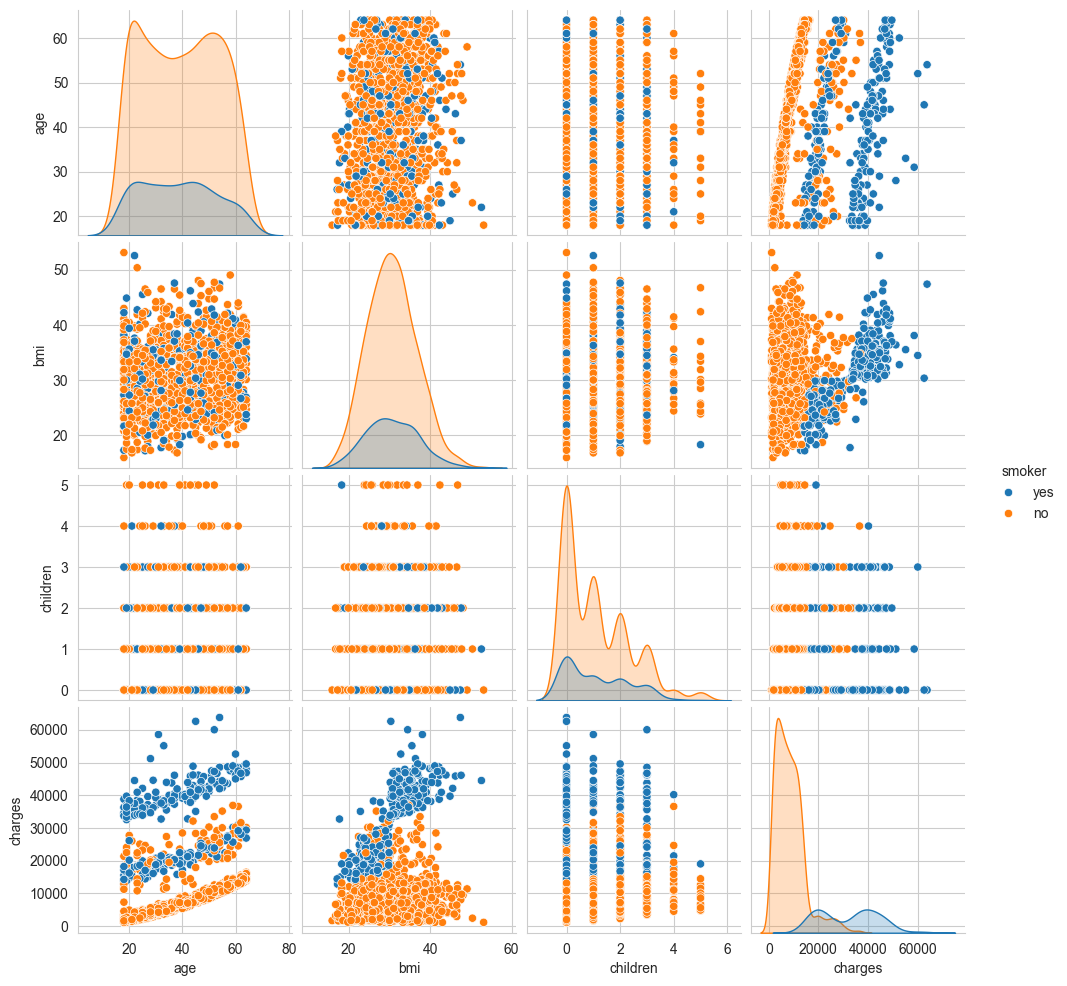

In [62]:
pairplot_cols = num_cols + ["smoker"]

df_pair = df[pairplot_cols].dropna()

sns.pairplot(df_pair, hue="smoker")
plt.show()

**Inference:**
- charges increase with age - especially with smoker=yes; clear clusters visible
- similar for bmi & charges (high charges for smokers with high bmi)

**6.2. Correlation heatmap**

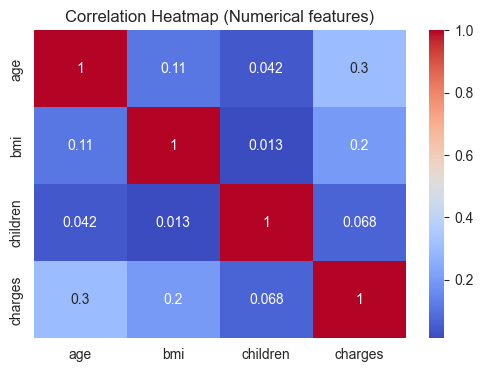

In [63]:
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical features)")
plt.show()

Inference:
- No high (+ve) or (-ve) correlation
- No multi-collinearity

**6.3. Cluster Map**

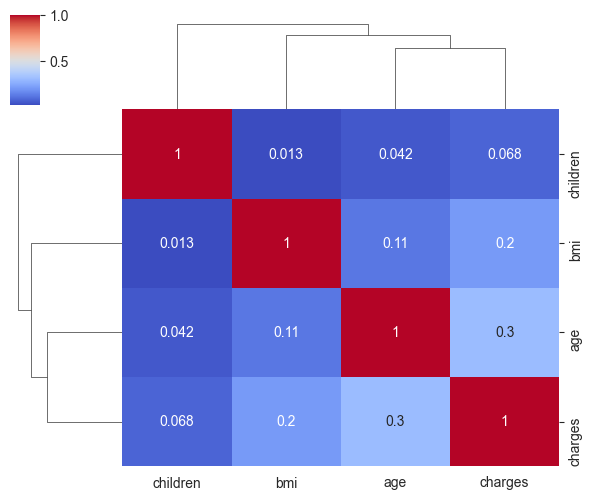

In [64]:
sns.clustermap(df[num_cols].corr(), annot=True, cmap="coolwarm", figsize=(6,5))
plt.show()

**6.4. Interaction & sub-group pattern**

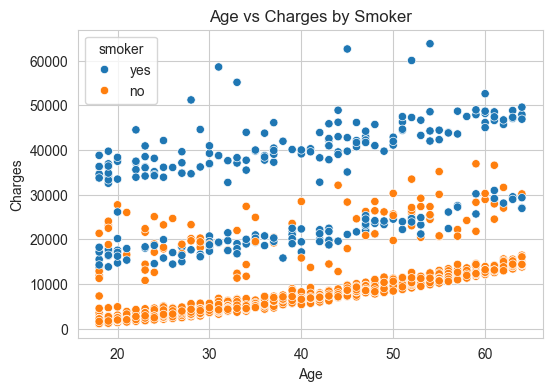

In [65]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age"], y=df["charges"], hue=df["smoker"])
plt.title("Age vs Charges by Smoker")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

**Inference:**
- Slight increase in Charges with Age
- Clear cluster showing high charges for smokers with Age

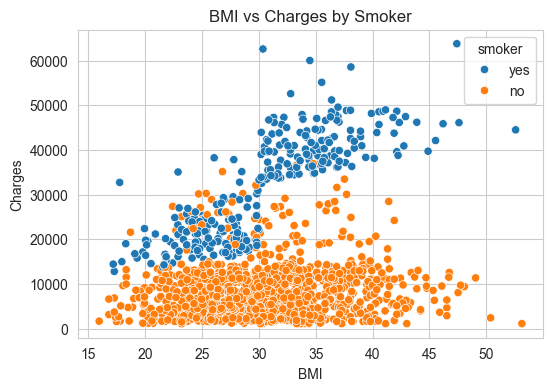

In [66]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["bmi"], y=df["charges"], hue=df["smoker"])
plt.title("BMI vs Charges by Smoker")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

**Inference:**
- Clear cluster showing high charges for smokers with high BMI

**6.5. Multivariate Analysis - Summary**

In [67]:
print("Multivariate ANalysis - Summary:")
print("- pairplot, heatmap, cluster map")
print("- Interaction and subgroup patterns plotted")

Multivariate ANalysis - Summary:
- pairplot, heatmap, cluster map
- Interaction and subgroup patterns plotted


### **7. Outliers - Detection**

In [68]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [69]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [70]:
print("Numerical Columns", num_cols)
print("Categorical Columns", cat_cols)

Numerical Columns ['age', 'bmi', 'children', 'charges']
Categorical Columns ['sex', 'smoker', 'region']


**7.1. Detect Outilers using Boxplots**

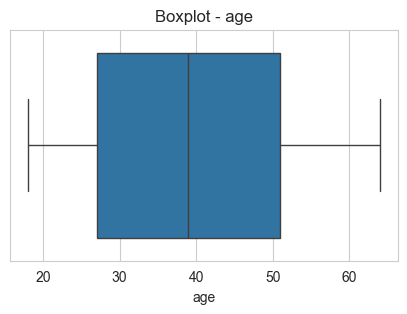

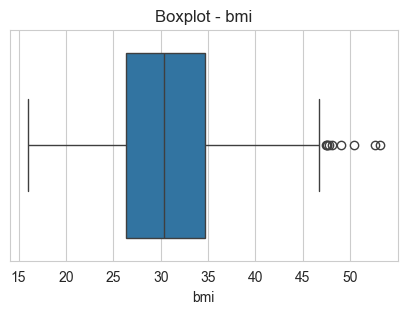

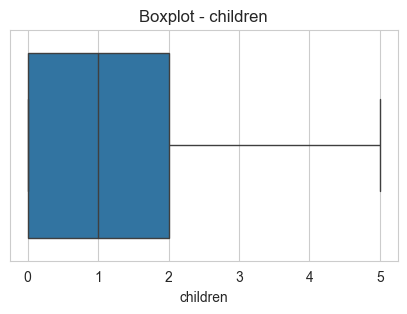

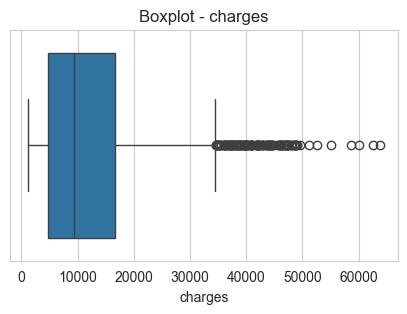

In [71]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

**Inference:**
- BMI columns has some Outliers (feature column)
- Charges column has several Outliers (target column)

**7.2. IQR Method**

In [72]:
def iqr_bounds(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    return lower_bound, upper_bound, iqr

In [74]:
for col in num_cols:
    col_clean = df[col].dropna()
    lower, upper, iqr = iqr_bounds(col_clean)
    outliers_mask = (col_clean < lower) | (col_clean > upper)
    num_outliers = outliers_mask.sum()
    total = col_clean.shape[0]

    print(f"\nIQR method for {col}:")
    print(f" Q1 - 1.5*IQR: {lower:.2f}")
    print(f" Q3 + 1.5*IQR: {upper:.2f}")
    print(f" IQR: {iqr:.2f}")
    print(f" Outliers: {num_outliers} out of {total}")


IQR method for age:
 Q1 - 1.5*IQR: -9.00
 Q3 + 1.5*IQR: 87.00
 IQR: 24.00
 Outliers: 0 out of 1338

IQR method for bmi:
 Q1 - 1.5*IQR: 13.70
 Q3 + 1.5*IQR: 47.29
 IQR: 8.40
 Outliers: 9 out of 1338

IQR method for children:
 Q1 - 1.5*IQR: -3.00
 Q3 + 1.5*IQR: 5.00
 IQR: 2.00
 Outliers: 0 out of 1338

IQR method for charges:
 Q1 - 1.5*IQR: -13109.15
 Q3 + 1.5*IQR: 34489.35
 IQR: 11899.63
 Outliers: 139 out of 1338


**7.3. Z-score Method**

|Z| = (value - mean) / std

|Z| > 3 as outliers

In [75]:
z_threshold = 3.0

for col in num_cols:
    col_clean = df[col].dropna()
    mean = col_clean.mean()
    std = col_clean.std()

    z_scores = (col_clean - mean) / std
    outliers_mask = np.abs(z_scores) > z_threshold
    num_outliers = outliers_mask.sum()
    total = col_clean.shape[0]

    print(f"\nZ score method for {col}:")
    print(f" Mean: {mean:.2f}, Std: {std:.2f}")
    print(f" Threshold: |Z| > {z_threshold}")
    print(f" Outliers: {num_outliers} out of {total}")


Z score method for age:
 Mean: 39.21, Std: 14.05
 Threshold: |Z| > 3.0
 Outliers: 0 out of 1338

Z score method for bmi:
 Mean: 30.66, Std: 6.10
 Threshold: |Z| > 3.0
 Outliers: 4 out of 1338

Z score method for children:
 Mean: 1.09, Std: 1.21
 Threshold: |Z| > 3.0
 Outliers: 18 out of 1338

Z score method for charges:
 Mean: 13270.42, Std: 12110.01
 Threshold: |Z| > 3.0
 Outliers: 7 out of 1338


**Inference:** As we can see, charges column is skewed and not in normal distribution & hence it's not ideal to use Z-score method to detect outliers for "charges" column

**7.4. Stat comparison after removing outliers in charges column**

**NOTE: Just for insights. shouldn't remove when model has to be trained**

In [77]:
charges_clean = df["charges"].dropna()
charges_lower, charges_upper, charges_iqr = iqr_bounds(charges_clean)

charges_inliers = charges_clean[(charges_clean >= charges_lower) & (charges_clean <= charges_upper)]

print("\'Charges' stats with outliers:")
print(f" Count: {charges_clean.shape[0]}")
print(f" Mean: {charges_clean.mean():.2f}")
print(f" Median: {charges_clean.median():.2f}")
print(f" Min: {charges_clean.min():.2f}, Max: {charges_clean.max():.2f}")

print("-"*50)

print("\'Charges' stats after removing IQR outliers:")
print(f" Count: {charges_inliers.shape[0]}")
print(f" Mean: {charges_inliers.mean():.2f}")
print(f" Median: {charges_inliers.median():.2f}")
print(f" Min: {charges_inliers.min():.2f}, Max: {charges_inliers.max():.2f}")

'Charges' stats with outliers:
 Count: 1338
 Mean: 13270.42
 Median: 9382.03
 Min: 1121.87, Max: 63770.43
--------------------------------------------------
'Charges' stats after removing IQR outliers:
 Count: 1199
 Mean: 9927.75
 Median: 8410.05
 Min: 1121.87, Max: 34472.84


**7.5. Outlier Detection - Sumary**

In [78]:
print("\nOutlier detection done.")
print("- Boxplots show extreme values in 'charges' column.")
print("- IQR method highlights numeric bounds and counts.")
print("- Z score method shows extreme standardized values.")
print("- 'charges' stats compared with and without outliers.")


Outlier detection done.
- Boxplots show extreme values in 'charges' column.
- IQR method highlights numeric bounds and counts.
- Z score method shows extreme standardized values.
- 'charges' stats compared with and without outliers.


---

## 8.7 Full EDA Project: Insights Summary

### Data Quality
- No missing values or encoded missing values found.
- One duplicate row identified.
- No constant or quasi constant columns.
- No ID-like columns.
- Data types are correct.

### Univariate Insights
- Age and BMI follow fairly normal patterns.
- Children has mild right skew.
- Charges is heavily right skewed with many extreme values.
- Smoker column is imbalanced. Regions are evenly distributed.

### Bivariate Insights
- Charges increase slightly with age.
- Charges increase with BMI.
- Smokers have significantly higher charges.
- Region has only a small effect on charges.

### Multivariate Insights
- Pairplot shows clear clusters for smokers with higher age and BMI.
- No strong correlations among predictors.
- Interaction plots highlight strong smoker patterns.

### Outliers
- Charges has many outliers and wide variation.
- BMI has a few outliers.

---

## Preprocessing Steps Required

1. **Encode Categorical Columns**
   - Convert sex, smoker and region to numeric form.
   - Use label or one hot encoding.

2. **Feature Scaling**
   - Scale numerical features for models like SVM, KNN or neural networks.

3. **Outlier Handling (optional)**
   - For linear models, consider log transform for charges or mild trimming.
   - Tree models can keep outliers.

4. **Handle Skewness**
   - Apply log transform on charges to reduce skew.

5. **Train Test Split**
   - Split the dataset before applying transformations.

6. **Optional Feature Engineering**
   - Age groups, BMI categories or interaction features if needed.


---

## Final Notes

- The dataset is clean and straightforward to work with.
- Smoking status is the strongest factor influencing charges.
- Charges distribution is skewed, so some transformations may help modeling.
- No multicollinearity found among numerical features.
- Good EDA builds a clear understanding of the data and guides the modeling plan.


---